Sales Forecasting — Phase 1: EDA
Rossmann Store Sales Dataset
 
Steps:
  1. Load & merge train.csv + store.csv
  2. Filter and clean
  3. Daily aggregated sales plot
  4. Single-store deep dive
  5. Seasonal decomposition (trend, seasonality, residual)
  6. ACF and PACF plots

### LOAD IMPORTANT LIBRARIES AND DATA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
 
plt.rcParams.update({"figure.facecolor": "white", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e5e5e5", "grid.linewidth": 0.6})

In [2]:
# LOAD & MERGE

train = pd.read_csv("data/train.csv", low_memory=False,
                    parse_dates=["Date"])
store = pd.read_csv("data/store.csv")
 
df = train.merge(store, on="Store", how="left")
 
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[ns]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  object        
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[ns](1), int64(7), object(1)
memory usage: 69.8+ MB
None


In [3]:
print(store.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB
None


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

### INSPECT DATA 

In [5]:
print("DATASET OVERVIEW")
print("=" * 60)
print(f"train.csv shape : {train.shape[0]:,} rows × {train.shape[1]} cols")
print(f"store.csv shape : {store.shape[0]:,} rows × {store.shape[1]} cols")
print(f"Merged shape    : {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Date range      : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Stores          : {df['Store'].nunique()}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing values:")
missing = df.isnull().sum()
print(missing[missing > 0].to_string())
print(f"\nFirst 5 rows:")
print(df[["Store","Date","Sales","Customers","Open","Promo",
          "StateHoliday","StoreType"]].head().to_string(index=False))

DATASET OVERVIEW
train.csv shape : 1,017,209 rows × 9 cols
store.csv shape : 1,115 rows × 10 cols
Merged shape    : 1,017,209 rows × 18 cols
Date range      : 2013-01-01 → 2015-07-31
Stores          : 1115

Columns: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']

Missing values:
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031

First 5 rows:
 Store       Date  Sales  Customers  Open  Promo StateHoliday StoreType
     1 2015-07-31   5263        555     1      1            0         c
     2 2015-07-31   6064        625     1      1            0         a
     3 2015-07-31   8314        821     1    

### DATA CLEANING AND FILTERING

In [6]:
# Keep only open stores with positive sales
# Closed stores (Open==0) and always have sales (Sales>0)
# Applying Masking with the above conditions
df_open = df[(df["Open"] == 1) & (df["Sales"] > 0)].copy()
 
print(f"\nAfter filtering Open==1 & Sales>0:")
print(f"  Rows remaining : {len(df_open):,}  "
      f"(removed {len(df)-len(df_open):,} closed-store rows)")
 
# Fill CompetitionDistance NaN with median because store has no nearby competitor
df_open["CompetitionDistance"] = df_open["CompetitionDistance"].fillna(
    df_open["CompetitionDistance"].median()
)

df_open = df_open.sort_values(["Store", "Date"]).reset_index(drop=True)
 
print(f"\nSales summary:")
print(df_open["Sales"].describe().round(0).to_string())
print(f"\nCustomers summary:")
print(df_open["Customers"].describe().round(0).to_string())


After filtering Open==1 & Sales>0:
  Rows remaining : 844,338  (removed 172,871 closed-store rows)

Sales summary:
count    844338.0
mean       6956.0
std        3104.0
min          46.0
25%        4859.0
50%        6369.0
75%        8360.0
max       41551.0

Customers summary:
count    844338.0
mean        763.0
std         401.0
min           8.0
25%         519.0
50%         676.0
75%         893.0
max        7388.0


### EXPLORATORY DATA ANALYSIS

</H> DAILY AGGREGATED SALES BY ALL STORES </H>


Daily aggregated sales:
  Days      : 942
  Avg daily total : €6,234,799
  Max daily total : €15,623,548


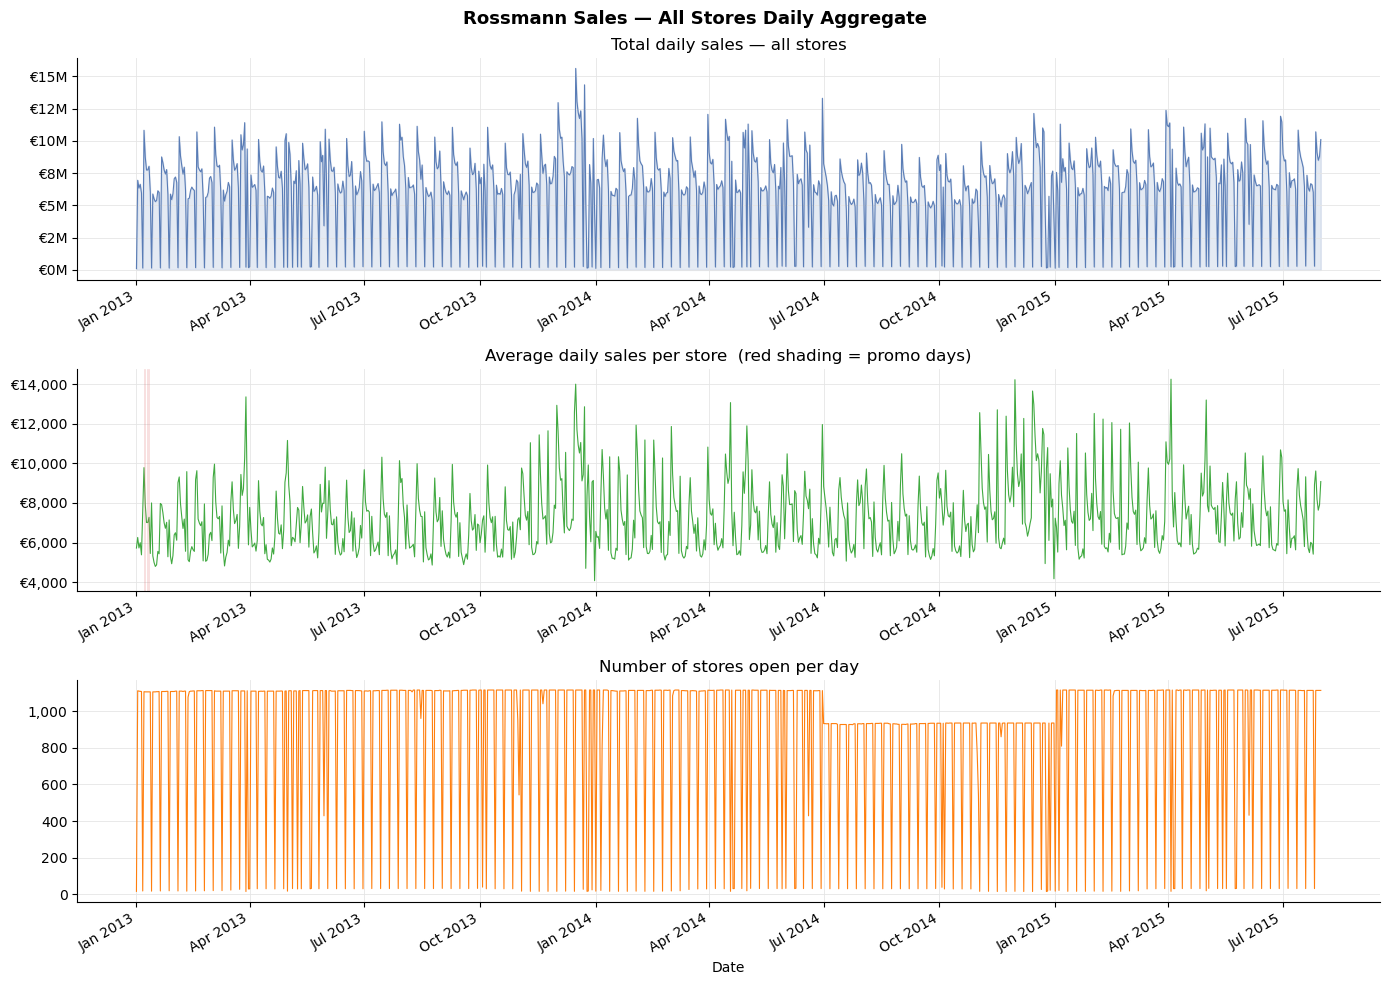

In [7]:
daily = df_open.groupby("Date").agg(
    TotalSales    =("Sales", "sum"),
    AvgSales      =("Sales", "mean"),
    StoresOpen    =("Store", "nunique"),
).reset_index()
 
print(f"\nDaily aggregated sales:")
print(f"  Days      : {len(daily)}")
print(f"  Avg daily total : €{daily['TotalSales'].mean():,.0f}")
print(f"  Max daily total : €{daily['TotalSales'].max():,.0f}")
 
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle("Rossmann Sales — All Stores Daily Aggregate",
             fontweight="bold", fontsize=13)

# Panel 1: Total daily sales
ax = axes[0]
ax.plot(daily["Date"], daily["TotalSales"] / 1e6,
        color="#4C72B0", linewidth=0.8, alpha=0.9)
ax.fill_between(daily["Date"], daily["TotalSales"] / 1e6,
                alpha=0.15, color="#4C72B0")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"€{x:.0f}M"))
ax.set_title("Total daily sales — all stores")
ax.set_xlabel("")

# Panel 2: Average daily sales per store
ax2 = axes[1]
ax2.plot(daily["Date"], daily["AvgSales"],
         color="#2ca02c", linewidth=0.8, alpha=0.9)
# Highlight promotions — aggregate promo rate per day
promo_daily = df_open.groupby("Date")["Promo"].mean()
promo_days  = promo_daily[promo_daily > 0.5].index
for d in promo_days[:5]:  # annotate first few
    ax2.axvline(d, color="#E07070", alpha=0.3, linewidth=0.5)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
ax2.set_title("Average daily sales per store  (red shading = promo days)")
ax2.set_xlabel("")


# Panel 3: Stores open per day
ax3 = axes[2]
ax3.plot(daily["Date"], daily["StoresOpen"],
         color="#FF7F0E", linewidth=0.8)
ax3.set_title("Number of stores open per day")
ax3.set_xlabel("Date")
ax3.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
 
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
 
plt.tight_layout()
plt.savefig("phase1_daily_sales.png", dpi=150, bbox_inches="tight")
plt.show()

### SINGLE STORE EXPLORATION


Store 1 deep dive:
  Days with sales : 781
  Avg daily sales : €4,759
  Max daily sales : €9,528
  Promo days      : 350 (44.8%)

  Promo sales lift: +22.7%


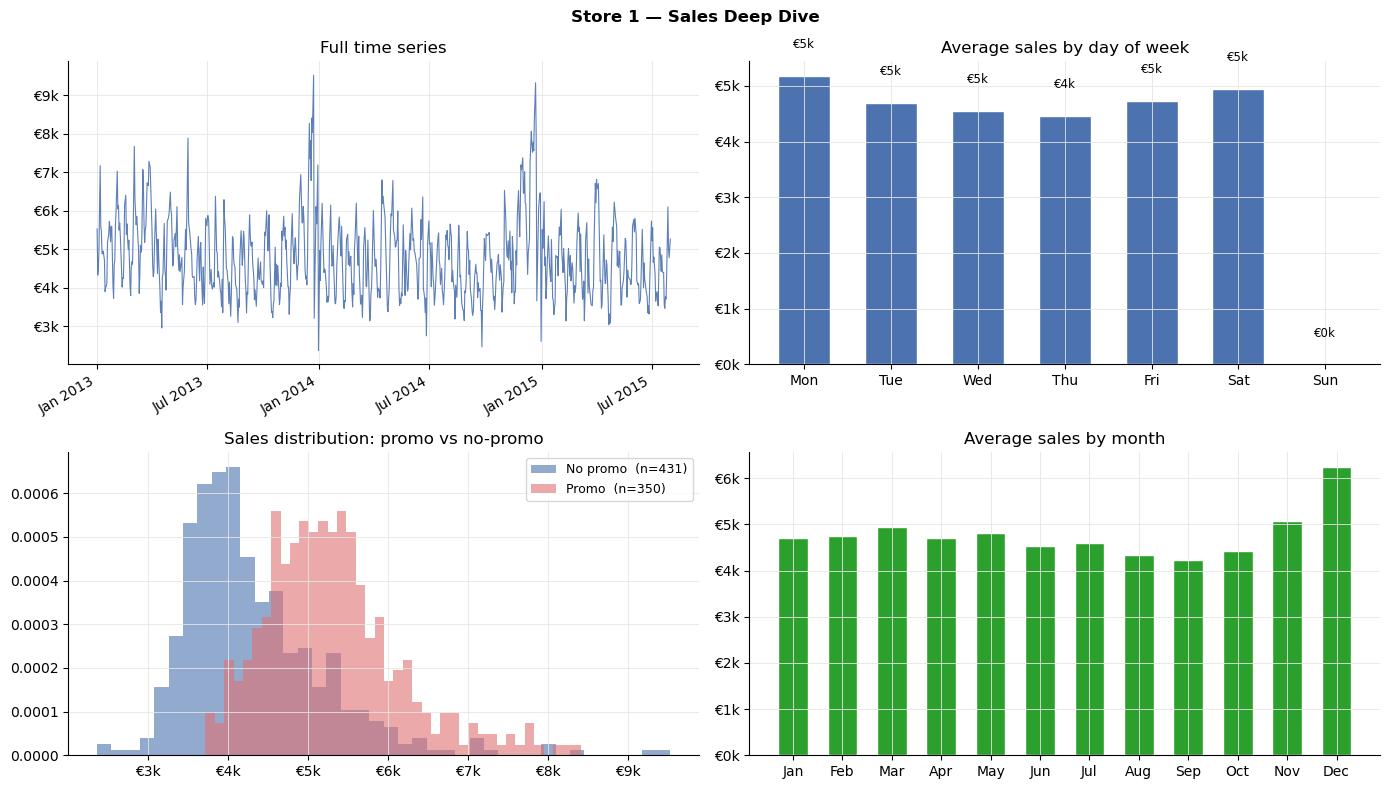

In [8]:
STORE_ID = 1
store_df  = df_open[df_open["Store"] == STORE_ID].copy()
store_ts  = store_df.set_index("Date")["Sales"].asfreq("D").fillna(method="ffill")
 
print(f"\nStore {STORE_ID} deep dive:")
print(f"  Days with sales : {len(store_df)}")
print(f"  Avg daily sales : €{store_df['Sales'].mean():,.0f}")
print(f"  Max daily sales : €{store_df['Sales'].max():,.0f}")
print(f"  Promo days      : {store_df['Promo'].sum()} "
      f"({store_df['Promo'].mean()*100:.1f}%)")
 
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f"Store {STORE_ID} — Sales Deep Dive", fontweight="bold")

# Panel 1: Full time series
ax = axes[0, 0]
ax.plot(store_df["Date"], store_df["Sales"],
        color="#4C72B0", linewidth=0.8, alpha=0.9)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
ax.set_title("Full time series")
ax.set_xlabel("")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

# Panel 2: Average sales by day of week
ax2 = axes[0, 1]

# Ensure all 7 days are present (1=Mon, 7=Sun)
dow_avg = (store_df.groupby("DayOfWeek")["Sales"]
           .mean()
           .reindex(range(1, 8), fill_value=0))

dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

bars = ax2.bar(dow_labels, dow_avg.values,
               color="#4C72B0", width=0.6, edgecolor="white")

ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
ax2.set_title("Average sales by day of week")

for bar, v in zip(bars, dow_avg.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 500,
             f"€{v/1000:.0f}k", ha="center", fontsize=8.5)

 
# Panel 3: Promo vs no-promo sales distribution
ax3 = axes[1, 0]
promo_sales    = store_df.loc[store_df["Promo"]==1, "Sales"]
no_promo_sales = store_df.loc[store_df["Promo"]==0, "Sales"]
ax3.hist(no_promo_sales, bins=40, alpha=0.6, color="#4C72B0",
         label=f"No promo  (n={len(no_promo_sales)})", density=True)
ax3.hist(promo_sales, bins=40, alpha=0.6, color="#E07070",
         label=f"Promo  (n={len(promo_sales)})", density=True)
ax3.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
ax3.set_title("Sales distribution: promo vs no-promo")
ax3.legend(fontsize=9)
promo_lift = (promo_sales.mean() / no_promo_sales.mean() - 1) * 100
print(f"\n  Promo sales lift: +{promo_lift:.1f}%")
 
# Panel 4: Monthly average sales
ax4 = axes[1, 1]
store_df["Month"] = store_df["Date"].dt.month
month_avg = store_df.groupby("Month")["Sales"].mean()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
bars4 = ax4.bar([month_labels[m-1] for m in month_avg.index],
                month_avg.values, color="#2ca02c", width=0.6, edgecolor="white")
ax4.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
ax4.set_title("Average sales by month")
 
plt.tight_layout()
plt.savefig("phase1_store_deep_dive.png", dpi=150, bbox_inches="tight")
plt.show()

### SEASONAL DECOMPOSITION AND EXPLORATION

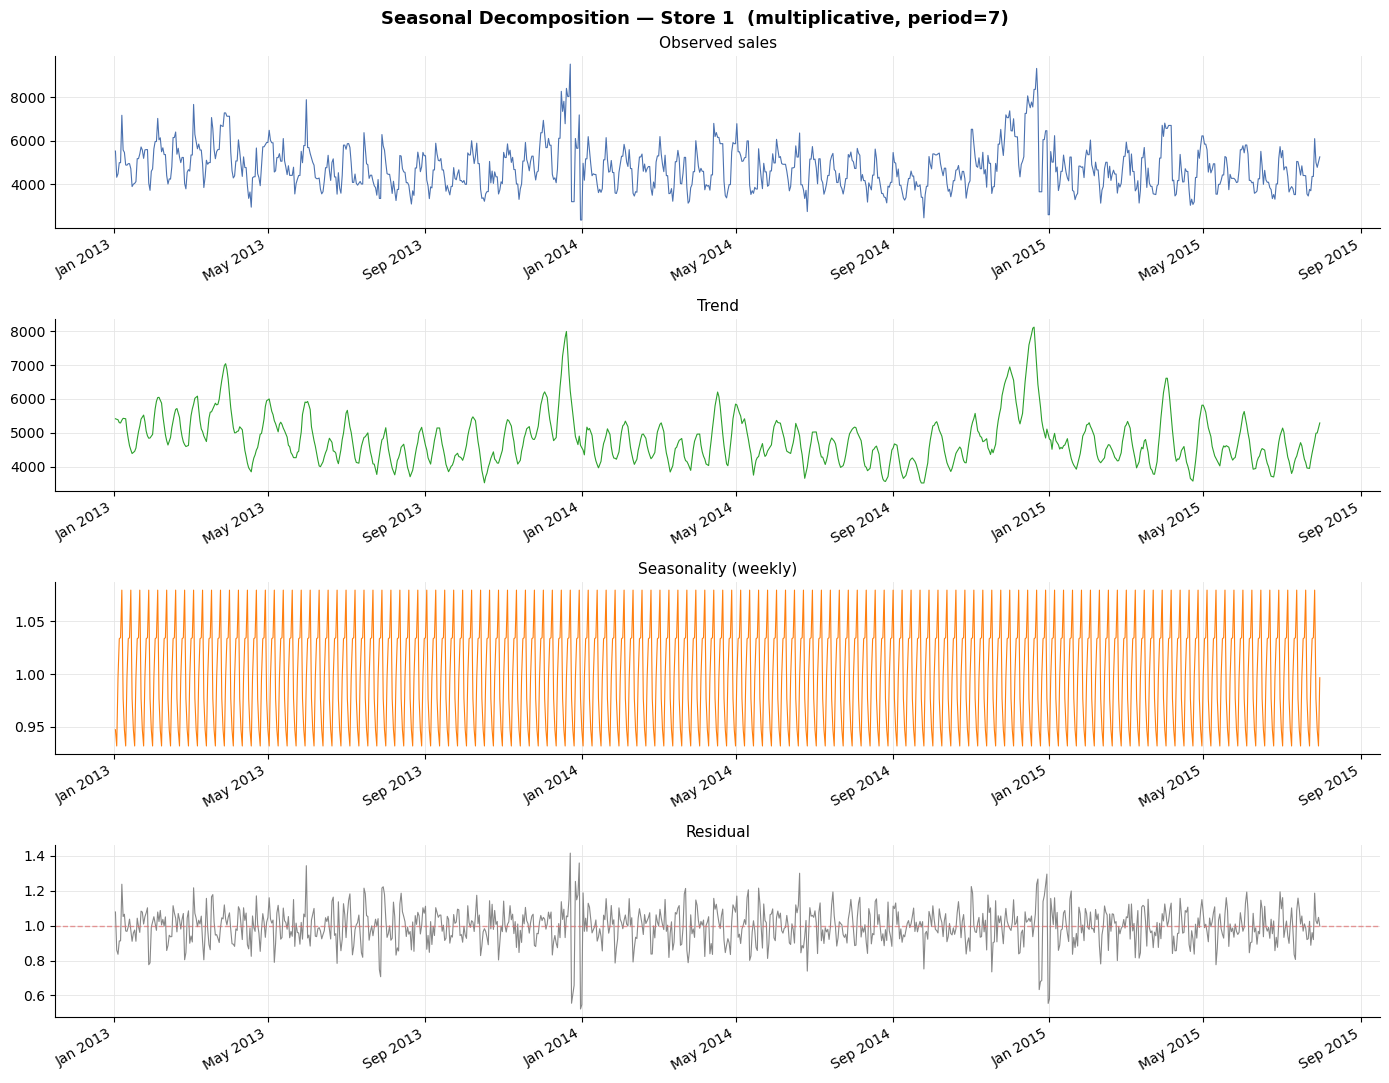

  Trend range   : €3,514 – €8,127
  Seasonal range: 0.932 – 1.080
  Residual std  : 0.1035


In [9]:
decomp = seasonal_decompose(store_ts, model="multiplicative",
                             period=7, extrapolate_trend="freq")
 
fig, axes = plt.subplots(4, 1, figsize=(14, 11))
fig.suptitle(f"Seasonal Decomposition — Store {STORE_ID}  (multiplicative, period=7)",
             fontweight="bold", fontsize=13)
 
components = [
    (store_ts,           "Observed sales",    "#4C72B0"),
    (decomp.trend,       "Trend",             "#2ca02c"),
    (decomp.seasonal,    "Seasonality (weekly)", "#FF7F0E"),
    (decomp.resid,       "Residual",          "#888"),
]
 
for ax, (data, title, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, linewidth=0.8)
    if title == "Residual":
        ax.axhline(1.0, color="#E07070", linestyle="--",
                   linewidth=1, alpha=0.7)
    ax.set_title(title, fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
 
plt.tight_layout()
plt.savefig("phase1_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
 
print(f"  Trend range   : €{decomp.trend.dropna().min():,.0f} – "
      f"€{decomp.trend.dropna().max():,.0f}")
print(f"  Seasonal range: {decomp.seasonal.min():.3f} – "
      f"{decomp.seasonal.max():.3f}")
print(f"  Residual std  : {decomp.resid.dropna().std():.4f}")

### ACF & PACF PLOTS
</p> ACF  — tells you the order of the MA component (q in ARIMA) </p></b>
</p>PACF — tells you the order of the AR component (p in ARIMA)</p></b>
Both inform parameter selection for Phase 2


Augmented Dickey-Fuller test (stationarity):
  Original series : ADF=-5.7685  p=0.0000  ✓ Stationary
  Differenced     : ADF=-10.4904  p=0.0000  ✓ Stationary

  If original is non-stationary → use d=1 in ARIMA
  If differenced is stationary  → d=1 is sufficient


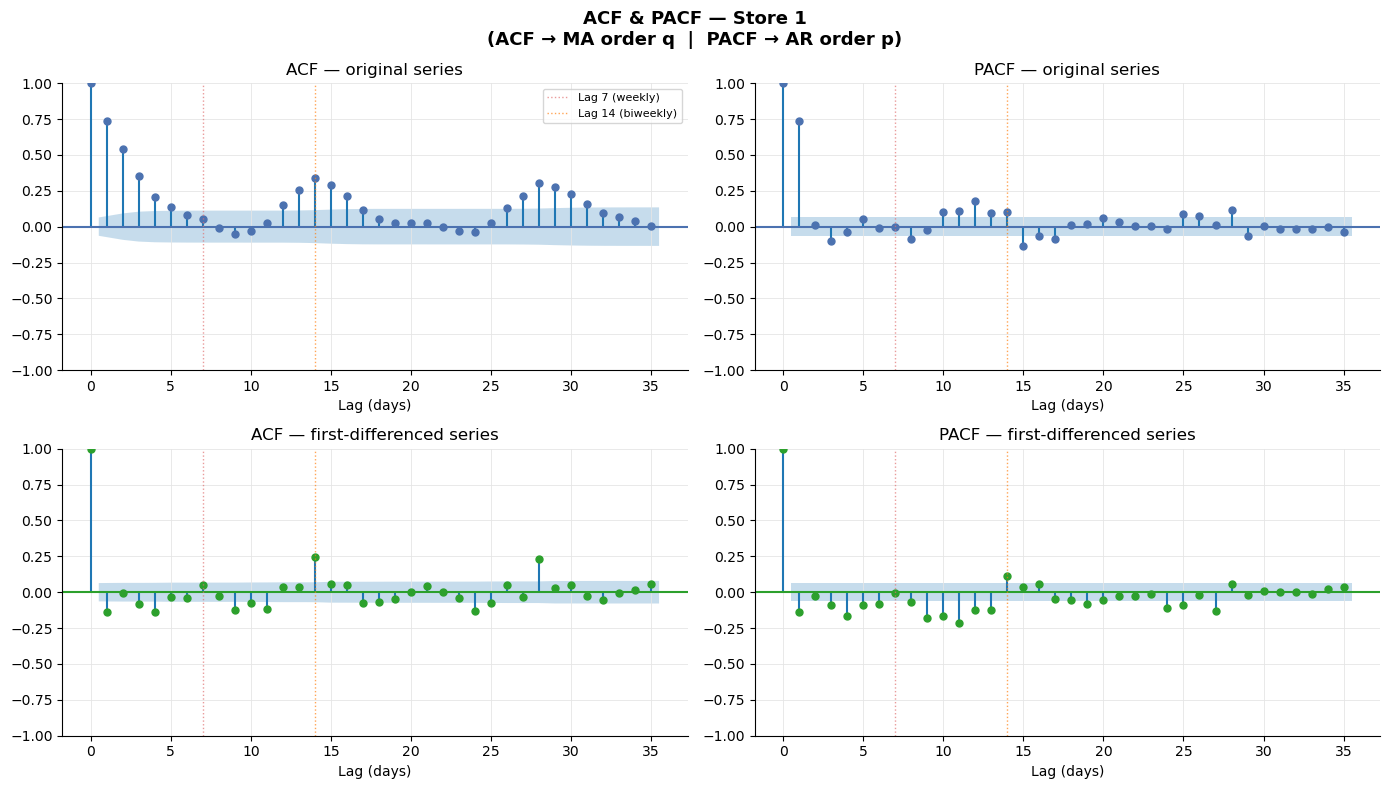


ACF/PACF interpretation guide:
  Significant spikes at lag 7, 14, 21 → weekly seasonal pattern
  PACF cuts off after lag p  → use AR(p) component
  ACF cuts off after lag q   → use MA(q) component
  These inform ARIMA(p,d,q)(P,D,Q,7) in Phase 2


In [10]:
# Difference the series to make it stationary
sales_diff = store_ts.diff().dropna()
 
# ADF test on original and differenced series
adf_orig = adfuller(store_ts.dropna())
adf_diff = adfuller(sales_diff)
 
print(f"\nAugmented Dickey-Fuller test (stationarity):")
print(f"  Original series : ADF={adf_orig[0]:.4f}  p={adf_orig[1]:.4f}  "
      f"{'✓ Stationary' if adf_orig[1] < 0.05 else '✗ Non-stationary'}")
print(f"  Differenced     : ADF={adf_diff[0]:.4f}  p={adf_diff[1]:.4f}  "
      f"{'✓ Stationary' if adf_diff[1] < 0.05 else '✗ Non-stationary'}")
print(f"\n  If original is non-stationary → use d=1 in ARIMA")
print(f"  If differenced is stationary  → d=1 is sufficient")
 
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f"ACF & PACF — Store {STORE_ID}\n"
             "(ACF → MA order q  |  PACF → AR order p)",
             fontweight="bold", fontsize=13)
 
LAGS = 35
 
# ACF — original
plot_acf(store_ts.dropna(), lags=LAGS, ax=axes[0, 0],
         color="#4C72B0", alpha=0.05)
axes[0, 0].set_title("ACF — original series")
axes[0, 0].set_xlabel("Lag (days)")
 
# PACF — original
plot_pacf(store_ts.dropna(), lags=LAGS, ax=axes[0, 1],
          color="#4C72B0", method="ywm", alpha=0.05)
axes[0, 1].set_title("PACF — original series")
axes[0, 1].set_xlabel("Lag (days)")
 
# ACF — differenced
plot_acf(sales_diff, lags=LAGS, ax=axes[1, 0],
         color="#2ca02c", alpha=0.05)
axes[1, 0].set_title("ACF — first-differenced series")
axes[1, 0].set_xlabel("Lag (days)")
 
# PACF — differenced
plot_pacf(sales_diff, lags=LAGS, ax=axes[1, 1],
          color="#2ca02c", method="ywm", alpha=0.05)
axes[1, 1].set_title("PACF — first-differenced series")
axes[1, 1].set_xlabel("Lag (days)")
 
for ax in axes.flatten():
    ax.axvline(7,  color="#E07070", linestyle=":", linewidth=1,
               alpha=0.7, label="Lag 7 (weekly)")
    ax.axvline(14, color="#FF7F0E", linestyle=":", linewidth=1,
               alpha=0.7, label="Lag 14 (biweekly)")
 
axes[0, 0].legend(fontsize=8)
 
plt.tight_layout()
plt.savefig("phase1_acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()
 
print(f"\nACF/PACF interpretation guide:")
print(f"  Significant spikes at lag 7, 14, 21 → weekly seasonal pattern")
print(f"  PACF cuts off after lag p  → use AR(p) component")
print(f"  ACF cuts off after lag q   → use MA(q) component")
print(f"  These inform ARIMA(p,d,q)(P,D,Q,7) in Phase 2")
 

### STORE TYPES AND SALES ANALYSIS

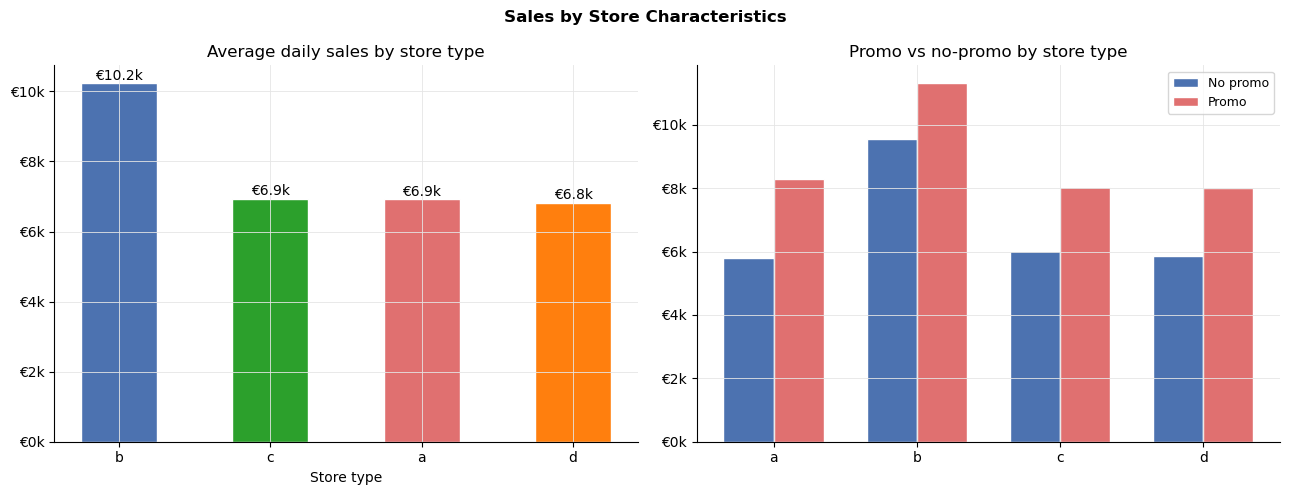

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Sales by Store Characteristics", fontweight="bold")
 
# Panel 1: Sales by StoreType
ax = axes[0]
store_type_avg = df_open.groupby("StoreType")["Sales"].mean().sort_values(ascending=False)
colors = ["#4C72B0", "#2ca02c", "#E07070", "#FF7F0E"]
bars = ax.bar(store_type_avg.index, store_type_avg.values,
              color=colors[:len(store_type_avg)], width=0.5, edgecolor="white")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
ax.set_title("Average daily sales by store type")
ax.set_xlabel("Store type")
for bar, v in zip(bars, store_type_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"€{v/1000:.1f}k", ha="center", fontsize=10)
 
# Panel 2: Promo effect by store type
ax2 = axes[1]
promo_effect = df_open.groupby(["StoreType", "Promo"])["Sales"].mean().unstack()
promo_effect.columns = ["No Promo", "Promo"]
x = np.arange(len(promo_effect))
w = 0.35
ax2.bar(x - w/2, promo_effect["No Promo"], w,
        color="#4C72B0", label="No promo", edgecolor="white")
ax2.bar(x + w/2, promo_effect["Promo"], w,
        color="#E07070", label="Promo", edgecolor="white")
ax2.set_xticks(x)
ax2.set_xticklabels(promo_effect.index)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
ax2.set_title("Promo vs no-promo by store type")
ax2.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("phase1_store_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# Saving  store Series for ARIMA and SARIMA Baseline
 
store_ts.to_csv(f"store_{STORE_ID}_daily_sales.csv", header=True)
df_open.to_csv("rossmann_clean.csv", index=False)
 
print(f"\nSaved:")
print(f"  store_{STORE_ID}_daily_sales.csv  ← used in Phase 2 (ARIMA)")
print(f"  rossmann_clean.csv")


Saved:
  store_1_daily_sales.csv  ← used in Phase 2 (ARIMA)
  rossmann_clean.csv
